# Regressão Logística I
## Tarefa II

Vamos trabalhar com a mesma base do exercício anterior, mas vamos aprofundar um pouco mais a nossa regressão.

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

import statsmodels.formula.api as smf

In [3]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data'

df = pd.read_csv(url, 
                 names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg',
                        'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'])
df['flag_doente'] = (df['num']!=0).astype('int64')
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num,flag_doente
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0,0


A descrição das variáveis está recortada abaixo:
- age: idade do paciente em anos
- sex: sexo (1 = male; 0 = female)  
- cp: tipo de dor no peito
  - 1: angina típica
  - 2: angina atípica
  - 3: dor não-angina
  - 4: assintomático
- trestbps: pressão sanguínea em repouso (em mm Hg na admissão ao hospital
- chol: colesterol sérico em mg/dl
- fbs: (açúcar no sangue em jejum > 120 mg/dl) (1 = True; 0 = False)
- restecg: resultados eletrocardiográficos em repouso
  - 0: normal
  - 1: tendo anormalidade da onda ST-T (Inversões de onda T e / ou ST com elevação ou depressão de > 0.05 mV)
  - 2: mostrando hipertrofia ventricular esquerda provável ou definitiva pelos critérios de Estes
- thalach: frequência cardíaca máxima alcançada
- exang: angina induzida por exercício(1 = sim; 0 = não)
- oldpeak = Depressão de ST induzida por exercício em relação ao repouso
- slope: Depressão de ST induzida por exercício em relação ao repouso
  - 1: inclinação ascendente
  - 2: estável
  - 3: inclinação descendente
- ca: número de vasos principais (0-3) coloridos por fluorosopia
- thal: 3 = normal; 6 = defeito corrigido; 7 = defeito reversível
- num: diagnóstico de doença cardíaga (status de doença angiográfica)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          303 non-null    float64
 1   sex          303 non-null    float64
 2   cp           303 non-null    float64
 3   trestbps     303 non-null    float64
 4   chol         303 non-null    float64
 5   fbs          303 non-null    float64
 6   restecg      303 non-null    float64
 7   thalach      303 non-null    float64
 8   exang        303 non-null    float64
 9   oldpeak      303 non-null    float64
 10  slope        303 non-null    float64
 11  ca           303 non-null    object 
 12  thal         303 non-null    object 
 13  num          303 non-null    int64  
 14  flag_doente  303 non-null    int64  
dtypes: float64(11), int64(2), object(2)
memory usage: 35.6+ KB


1. Considere o script que monta a análise bivariada que você fez na tarefa anterior. Transforme esse script em uma função, que deve:
- Ter como parâmetros de entrada:
    - Um *dataframe* contendo os dados a serem avaliados
    - Um *string* contendo o nome da variável resposta
    - Um *string* contendo o nome da variável explicativa
- E deve retornar um *dataframe* com os dados da bivariada. 
**Monte** a mesma bivariada pelo menos três variáveis qualitativas do *data-frame*. Qual delas parece discriminar mais o risco?

In [6]:
def monta_bivariada(df, variavel_resposta, variavel_explicativa):
    tab = pd.crosstab(df[variavel_explicativa], df[variavel_resposta], margins=True)
    
    tab.columns = ['saudavel', 'doente', 'All']
    
    tab['prob_evento'] = tab['doente'] / tab['All']
    tab['odds'] = tab['doente'] / tab['saudavel']
    tab['odds_ratio'] = tab['odds'] / tab.loc['All', 'odds']
    tab['logito'] = np.log(tab['odds'])
    tab['woe'] = np.log(tab['odds_ratio'])
    
    return tab

2. Monte uma função semelhante para categorizar variáveis quantitativas contínuas (com muitas categorias) como ```age```.  
    Além dos mesmos parâmetros da função anterior, defina mais um parâmetro como número de categorias que você deseja quebrar. Defina um valor '*default*' de 5 grupos para este parâmetro.  

In [7]:
print("--- Análise Bivariada: SEX ---")
biv_sex = monta_bivariada(df, 'flag_doente', 'sex')
display(biv_sex)

print("\n--- Análise Bivariada: CP ---")
biv_cp = monta_bivariada(df, 'flag_doente', 'cp')
display(biv_cp)

print("\n--- Análise Bivariada: EXANG ---")
biv_exang = monta_bivariada(df, 'flag_doente', 'exang')
display(biv_exang)

--- Análise Bivariada: SEX ---


,saudavel,doente,All,prob_evento,odds,odds_ratio,logito,woe
sex,,,,,,,,
0.0,72,25,97,0.257732,0.347222,0.409672,-1.057790,-0.892398
1.0,92,114,206,0.553398,1.239130,1.461996,0.214410,0.379802
All,164,139,303,0.458746,0.847561,1.000000,-0.165392,0.000000



--- Análise Bivariada: CP ---


,saudavel,doente,All,prob_evento,odds,odds_ratio,logito,woe
cp,,,,,,,,
1.0,16,7,23,0.304348,0.437500,0.516187,-0.826679,-0.661286
2.0,41,9,50,0.180000,0.219512,0.258993,-1.516347,-1.350955
3.0,68,18,86,0.209302,0.264706,0.312315,-1.329136,-1.163743
4.0,39,105,144,0.729167,2.692308,3.176536,0.990399,1.155791
All,164,139,303,0.458746,0.847561,1.000000,-0.165392,0.000000



--- Análise Bivariada: EXANG ---


,saudavel,doente,All,prob_evento,odds,odds_ratio,logito,woe
exang,,,,,,,,
0.0,141,63,204,0.308824,0.446809,0.527170,-0.805625,-0.640233
1.0,23,76,99,0.767677,3.304348,3.898655,1.195239,1.360632
All,164,139,303,0.458746,0.847561,1.000000,-0.165392,0.000000


3. Construa um modelo de regressão logística com as variáveis qualitativas: ```sex + cp +  trestbps``` e com a variável quantitativa ```age```.

**Interprete os parâmetros.**

In [8]:
import statsmodels.formula.api as smf
import numpy as np

# 1. Ajustando o modelo com as variáveis solicitadas
# Nota: 'sex', 'cp' e 'trestbps' são tratadas como explicativas
modelo = smf.logit("flag_doente ~ sex + cp + trestbps + age", data=df).fit()

# Exibindo o sumário estatístico
print(modelo.summary())

# 2. Calculando os Odds Ratio (Exponencial dos coeficientes) para facilitar a interpretação
print("\n--- Odds Ratio ---")
print(np.exp(modelo.params))

Optimization terminated successfully.
         Current function value: 0.510076
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:            flag_doente   No. Observations:                  303
Model:                          Logit   Df Residuals:                      298
Method:                           MLE   Df Model:                            4
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.2605
Time:                        23:41:04   Log-Likelihood:                -154.55
converged:                       True   LL-Null:                       -208.99
Covariance Type:            nonrobust   LLR p-value:                 1.264e-22
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -11.1167      1.608     -6.915      0.000     -14.267      -7.966
sex            1.8021      0.

4. Avalie o seu modelo quanto a **calibragem**:
- Calcule a probabilidade de evento predita segundo o seu modelo
- Categorize essa probabilidade em G=5 grupos
- Calcule a probabilidade de evento predita média por grupo
- Calcule a taxa de eventos (média da variável indicadora de eventos) por grupo
- Compare graficamente o valor eperado versus observado para a taxa de maus por grupo

Optimization terminated successfully.
         Current function value: 0.510076
         Iterations 6


/var/folders/6l/pm8nf4cs7cvfkrgnqlp9p3vm0000gn/T/ipykernel_3944/885223152.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_calib = df.groupby('cat_predito').agg(


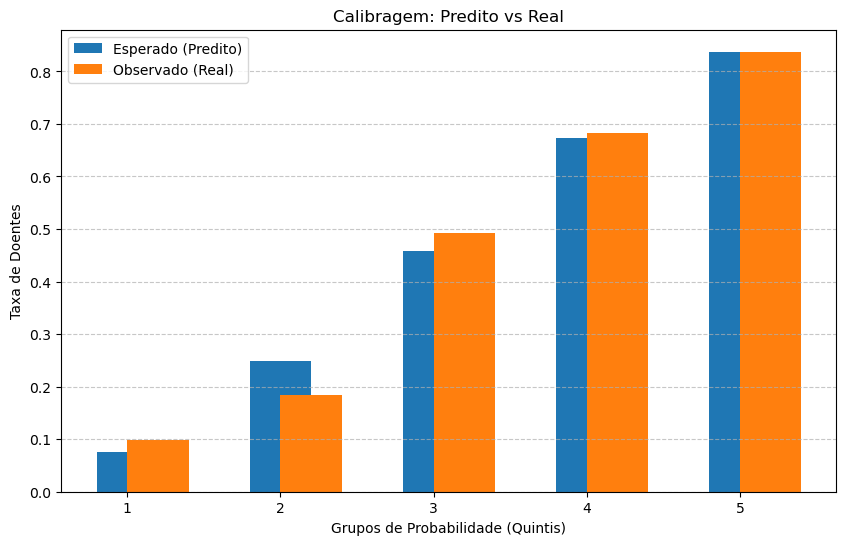

In [10]:
reglog = smf.logit("flag_doente ~ sex + cp + trestbps + age", data=df).fit()

df['predito'] = reglog.predict(df)

df['cat_predito'] = pd.qcut(df['predito'], q=5)

group_calib = df.groupby('cat_predito').agg(
    predito_medio=('predito', 'mean'),
    taxa_real=('flag_doente', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
plt.bar(range(1, 6), group_calib['predito_medio'], width=0.4, label='Esperado (Predito)', align='center')
plt.bar(range(1, 6), group_calib['taxa_real'], width=0.4, label='Observado (Real)', align='edge')

plt.title('Calibragem: Predito vs Real')
plt.xlabel('Grupos de Probabilidade (Quintis)')
plt.ylabel('Taxa de Doentes')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

5. Avalie o seu modelo quanto a discriminação calculando acurácia, GINI e KS.

In [11]:
from sklearn.metrics import roc_auc_score, accuracy_score


acc = accuracy_score(df['flag_doente'], (df['predito'] > 0.5).astype(int))


auc = roc_auc_score(df['flag_doente'], df['predito'])
gini = 2 * auc - 1

def calculat_ks(data, real_col, pred_col):
    df_ks = data[[real_col, pred_col]].sort_values(by=pred_col, ascending=False).reset_index(drop=True)
    
    n_eventos = df_ks[real_col].sum()
    n_nao_eventos = len(df_ks) - n_eventos
    
    cum_eventos = df_ks[real_col].cumsum() / n_eventos
    cum_nao_eventos = (1 - df_ks[real_col]).cumsum() / n_nao_eventos
    
    return max(abs(cum_eventos - cum_nao_eventos))

ks = calculat_ks(df, 'flag_doente', 'predito')

print(f"Acurácia: {acc:.2%}")
print(f"AUC:      {auc:.2%}")
print(f"GINI:     {gini:.2%}")
print(f"KS:       {ks:.2%}")

Acurácia: 77.89%
AUC:      83.11%
GINI:     66.22%
KS:       58.40%


6. tente melhorar o modelo obtido, por exemplo inserindo ou removendo variáveis.  
    Avalie as características do seu modelo (calibragem e acurácia).

In [12]:
modelo_melhorado = smf.logit("flag_doente ~ age + sex + cp + trestbps + thalach + oldpeak", data=df).fit()

print(modelo_melhorado.summary())

df['predito_novo'] = modelo_melhorado.predict(df)

Optimization terminated successfully.
         Current function value: 0.441532
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:            flag_doente   No. Observations:                  303
Model:                          Logit   Df Residuals:                      296
Method:                           MLE   Df Model:                            6
Date:                Mon, 25 May 2026   Pseudo R-squ.:                  0.3599
Time:                        23:57:04   Log-Likelihood:                -133.78
converged:                       True   LL-Null:                       -208.99
Covariance Type:            nonrobust   LLR p-value:                 6.325e-30
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.1214      2.211     -2.316      0.021      -9.455      -0.787
age            0.0251      0.

Nova Acurácia: 78.55%
Novo GINI:     74.84%


/var/folders/6l/pm8nf4cs7cvfkrgnqlp9p3vm0000gn/T/ipykernel_3944/2806792802.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_calib_novo = df.groupby('cat_predito_novo').agg(


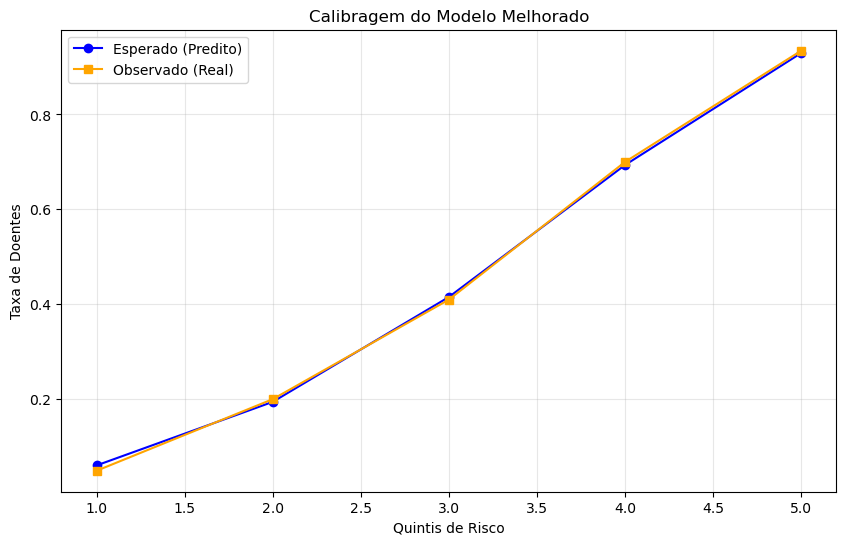

In [13]:
from sklearn.metrics import accuracy_score, roc_auc_score

acc_nova = accuracy_score(df['flag_doente'], (df['predito_novo'] > 0.5).astype(int))
auc_novo = roc_auc_score(df['flag_doente'], df['predito_novo'])
gini_novo = 2 * auc_novo - 1

print(f"Nova Acurácia: {acc_nova:.2%}")
print(f"Novo GINI:     {gini_novo:.2%}")

df['cat_predito_novo'] = pd.qcut(df['predito_novo'], q=5)
group_calib_novo = df.groupby('cat_predito_novo').agg(
    predito_medio=('predito_novo', 'mean'),
    taxa_real=('flag_doente', 'mean')
).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(range(1, 6), group_calib_novo['predito_medio'], marker='o', label='Esperado (Predito)', color='blue')
plt.plot(range(1, 6), group_calib_novo['taxa_real'], marker='s', label='Observado (Real)', color='orange')

plt.title('Calibragem do Modelo Melhorado')
plt.xlabel('Quintis de Risco')
plt.ylabel('Taxa de Doentes')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()